# Epic of Sun - Desafio 1
Preprocessing the data in scenes to check the pipeline
***

This jupyter notebook preprocesses the data and creates images of the scenes to check alignment and regions of interest

It is divided in 4 parts:
* Loading libraries anda data
* Transforming the dataset
* Normalization
* Producing the images

***

## Loading libraries and data

In [233]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from shapely.geometry import box
from rasterio.windows import Window
from affine import Affine

import json
import joblib
from pathlib import Path
import os

In [234]:
# Get the directory where THIS script is located
base_path = Path.cwd()
base_path = base_path.parent  # Move one level up to the project root

In [235]:
# Function to merge the 4 bands into a single 4-channel image and return the image
# This is done for a preview of the entire scene and a smaller cropped version for training
def create_merged_scene_file(
	scene_folder, 
	output_filepath, 
	preview_filepath, 
	crop=(0.4, 0.7, 0.0, 0.3),
    preview_scale=8):
    """
    Merges individual Sentinel bands (B02, B03, B04, B08) from a scene folder 
    into a single multi-band GeoTIFF file on disk.
    """

    x0, x1, y0, y1 = crop

    scene_folder = Path(scene_folder)
    output_filepath = Path(output_filepath)
    output_filepath.parent.mkdir(parents=True, exist_ok=True)

    band_patterns = {
        "blue": "*B02_10m.jp2",
        "green": "*B03_10m.jp2",
        "red": "*B04_10m.jp2",
        "nir": "*B08_10m.jp2",
    }

    band_files = {}
    for color, pattern in band_patterns.items():
		#matches = list((scene_folder / "bands").glob(pattern))
        matches = list((scene_folder).glob(pattern))
        if not matches:
            raise FileNotFoundError(f"Could not find band file matching {pattern} in {scene_folder / 'bands'}")
        band_files[color] = matches[0]

    arrays = []
    preview_arrays = []
    profile = None

    # Open files and read data
    for file in band_files.values():
        with rasterio.open(file) as src:

            width = src.width
            height = src.height

			# Low resolution preview for quick visualization
            if preview_filepath is not None:

                preview = src.read(
					1,
					out_shape=(
						height // preview_scale,
						width // preview_scale
					),
					resampling=rasterio.enums.Resampling.bilinear
				)

                preview_arrays.append(preview)

            # Crop window
            window = Window(
                col_off=int(width * x0),
                row_off=int(height * y0),
                width=int(width * (x1 - x0)),
                height=int(height * (y1 - y0))
            )

            # Read only the selected region
            arrays.append(src.read(1, window=window))

            if profile is None:
                preview_profile = src.profile.copy()

                preview_transform = src.transform * Affine.scale(preview_scale)

                preview_profile.update({
					"driver": "GTiff",
					"width": width // preview_scale,
					"height": height // preview_scale,
					"transform": preview_transform,
					"count": len(band_patterns),
					"dtype": rasterio.float32,
					"compress": "deflate"
                })

                profile = src.profile.copy()

                # Update transform for the cropped image
                profile.update({
                    "driver": "GTiff",
                    "width": window.width,
                    "height": window.height,
                    "transform": rasterio.windows.transform(window, src.transform),
                    "count": len(band_patterns),
                    "dtype": rasterio.float32,
                    "compress": "deflate"
                })

	# Write the preview multi-band raster to disk
    with rasterio.open(preview_filepath, "w", **preview_profile) as dst:
        for i, band in enumerate(preview_arrays, start=1):
            dst.write(band, i)

    # Write the merged multi-band raster to disk
    with rasterio.open(output_filepath, 'w', **profile) as dst:
        for idx, array in enumerate(arrays, start=1):
            dst.write(array, idx)

    print(f"Merged scene saved to: {output_filepath}")
    print(f"Preview scene saved to: {preview_filepath}")
    return output_filepath

In [ ]:
# Controls for processing a single scene
scene = "scene01" # Replace with the actual scene name you want to process
crop = (0.35, 0.65, 0.35, 0.65)  # Crop to the central region of the image (x0, x1, y0, y1)

folder_scene = base_path / "data" / "raw" / scene
folder_output = base_path / "data" / "test" / f"{scene}_merged.tif"
preview_output = base_path / "data" / "test" / f"{scene}_preview.tif"

# Process one scene for test and demonstration
create_merged_scene_file(
	folder_scene, 
	folder_output, 
	preview_output,
	crop=crop,
	preview_scale=8
)

Merged scene saved to: /home/fdesmello/Git/spacesugar/data/test/scene10_merged.tif
Preview scene saved to: /home/fdesmello/Git/spacesugar/data/test/scene10_preview.tif


PosixPath('/home/fdesmello/Git/spacesugar/data/test/scene10_merged.tif')

In [237]:
# Specify the paths to the poligons and image files
mesh = base_path / "data" / "raw" / "mask" / "sugarcane_mesh.shp"
image = base_path / "data" / "test" / f"{scene}_merged.tif"
image_preview = base_path / "data" / "test" / f"{scene}_preview.tif"

In [238]:
# Load sugarcane poligons map
mesh_raw = gpd.read_file(mesh)

In [239]:
# Load merged cropped satellite images
with rasterio.open(image) as image_src:
	# Read image bands
    image_raw = image_src.read()  # bands, height, width
    image_meta = image_src.meta.copy()

In [240]:
# Load preview satellite images
with rasterio.open(image_preview) as image_preview_src:
	# Read preview image bands
    image_preview_raw = image_preview_src.read()  # bands, height, width
    image_preview_meta = image_preview_src.meta.copy()

## Transforming the data

In [241]:
# Verify projections. They must be the same for the rasterization to work properly
print("Mesh projection: ", mesh_raw.crs)
print("Image projection:", image_src.crs)

Mesh projection:  EPSG:4326
Image projection: EPSG:32723


In [242]:
# Force the Shapefile to use the same projection (CRS) as the images
mesh_aligned = mesh_raw.to_crs(image_src.crs)
print("Mesh projection: ", mesh_aligned.crs)

Mesh projection:  PROJCS["WGS 84 / UTM zone 23S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-45],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32723"]]


In [243]:
# Size of the mesh
print(len(mesh_aligned))

578571


In [244]:
# Cropping the mesh to the preview scene size

preview_transform = image_preview_meta["transform"]

xmin = preview_transform.c
ymax = preview_transform.f

xmax = xmin + image_preview_meta["width"] * preview_transform.a
ymin = ymax + image_preview_meta["height"] * preview_transform.e

bbox = box(xmin, ymin, xmax, ymax)

mesh_preview = gpd.clip(mesh_aligned, bbox)

In [245]:
# Size of the preview cropped mesh
print(len(mesh_preview))

16822


In [246]:
# Cropping the mesh to the merged scene size

xmin = image_meta["transform"].c
ymax = image_meta["transform"].f

xmax = xmin + image_meta["width"] * image_meta["transform"].a
ymin = ymax + image_meta["height"] * image_meta["transform"].e

bbox = box(xmin, ymin, xmax, ymax)

mesh_aligned = gpd.clip(mesh_aligned, bbox)

In [247]:
# Size of the merged cropped mesh
print(len(mesh_aligned))

2016


In [248]:
# Normalization
# =====================================================================
# Satelites images come in high integer values (ex: 0 to 10000). 
# Neural networks work better with float values between 0 and 1.

# Many Sentinel products are stored as UInt16, whose maximum is 65535. 
# Some providers preserve that full range, even if most reflectance 
# values are much lower. Let's check the data type and range of the 
# image to determine the appropriate normalization factor.

print("Image data type:    ", image_raw.dtype)
print("Image minimum value:", image_raw.min())
print("Image maximum value:", image_raw.max())
print("Image height:", image_meta["height"])
print("Image width:", image_meta["width"])

Image data type:     float32
Image minimum value: 537.0
Image maximum value: 10152.0
Image height: 3294
Image width: 3294


In [249]:
# Check range for each band separately
for i, band in enumerate(image_raw):
    print(
        f"Band {i}:",
        band.min(),
        band.max()
    )

Band 0: 537.0 9200.0
Band 1: 775.0 8060.0
Band 2: 698.0 10152.0
Band 3: 1075.0 8616.0


In [250]:
# Check how many pixels have the maximum value (65535) in each band
for i in range(image_raw.shape[0]):
    print(f"Band {i}:", np.sum(image_raw[i] == 65535))

Band 0: 0
Band 1: 0
Band 2: 0
Band 3: 0


In [251]:
# checking metadata of the image
print(image_meta)

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': None, 'width': 3294, 'height': 3294, 'count': 4, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 23S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-45],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32723"]]'), 'transform': Affine(10.0, 0.0, 238400.0,
       0.0, -10.0, 7561580.0)}


In [252]:
# checking metadata of the image
for key, value in image_meta.items():
    print(f"{key}: {value}")

driver: GTiff
dtype: float32
nodata: None
width: 3294
height: 3294
count: 4
crs: EPSG:32723
transform: | 10.00, 0.00, 238400.00|
| 0.00,-10.00, 7561580.00|
| 0.00, 0.00, 1.00|


In [253]:
# Checking distribution of pixel values in each band
for i in range(image_raw.shape[0]):
    band = image_raw[i]

    print(
        f"\nBand {i}",
        "\n  min =", band.min(),
        "\n  max =", band.max(),
        "\n  99% =", np.percentile(band,99),
        "\n  99.9% =", np.percentile(band,99.9)
    )


Band 0 
  min = 537.0 
  max = 9200.0 
  99% = 1902.0 
  99.9% = 2460.0

Band 1 
  min = 775.0 
  max = 8060.0 
  99% = 2310.0 
  99.9% = 2906.0

Band 2 
  min = 698.0 
  max = 10152.0 
  99% = 2954.0 
  99.9% = 3618.0

Band 3 
  min = 1075.0 
  max = 8616.0 
  99% = 4936.0 
  99.9% = 5588.0



Visualization saved as '/home/fdesmello/Git/spacesugar/figures/histograms_scene10.png'


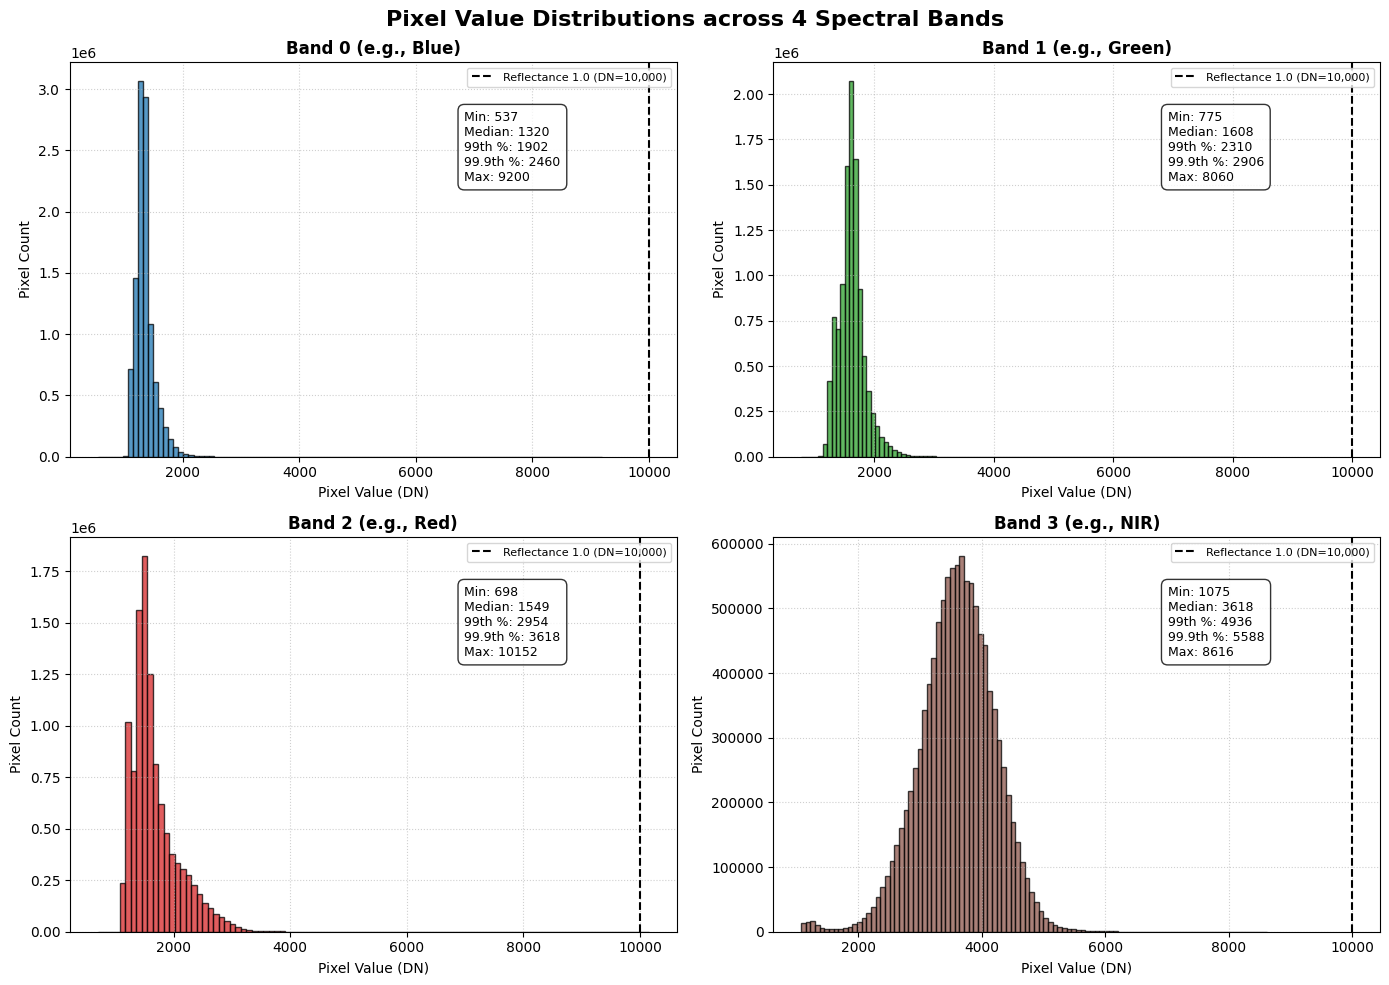

In [254]:
# Histogram of pixel values for each band

# --- Configuration ---
band_names = [
    "Band 0 (e.g., Blue)",
    "Band 1 (e.g., Green)",
    "Band 2 (e.g., Red)",
    "Band 3 (e.g., NIR)",
]
colors = ["#1f77b4", "#2ca02c", "#d62728", "#8c564b"]  # Distinct plotting colors

# Setup a 2x2 grid of subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10), sharey=False)
axes = axes.flatten()

# --- Plot Histograms ---
for b in range(4):
    band_data = image_raw[b].ravel()  # Flatten 2D band into 1D array

    # Optional: Filter out zero/nodata values if present
    band_data = band_data[band_data > 0]

    # Calculate summary statistics for the annotation box
    p99 = np.percentile(band_data, 99.0)
    p999 = np.percentile(band_data, 99.9)
    median_val = np.median(band_data)

    # Plot histogram
    ax = axes[b]
    ax.hist(band_data, bins=100, color=colors[b], alpha=0.75, edgecolor="black")

    # Add reference lines for physical reflectance scale (DN = 10,000)
    ax.axvline(
        10000,
        color="black",
        linestyle="--",
        linewidth=1.5,
        label="Reflectance 1.0 (DN=10,000)",
    )

    # Formatting subplots
    ax.set_title(band_names[b], fontsize=12, fontweight="bold")
    ax.set_xlabel("Pixel Value (DN)", fontsize=10)
    ax.set_ylabel("Pixel Count", fontsize=10)
    ax.grid(True, linestyle=":", alpha=0.6)

    # Add text overlay with quick stats
    stats_text = (
        f"Min: {band_data.min():.0f}\n"
        f"Median: {median_val:.0f}\n"
        f"99th %: {p99:.0f}\n"
        f"99.9th %: {p999:.0f}\n"
        f"Max: {band_data.max():.0f}"
    )
    ax.text(
        0.65,
        0.70,
        stats_text,
        transform=ax.transAxes,
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.8),
    )
    ax.legend(loc="upper right", fontsize=8)

plt.suptitle(
    "Pixel Value Distributions across 4 Spectral Bands",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)
plt.tight_layout()

# Save and display the final aligned result
file_path = base_path / "figures" / f"histograms_{scene}.png"
plt.savefig(file_path, dpi=300, bbox_inches='tight')
print(f"\nVisualization saved as '{file_path}'")
plt.show()

## Normalization

In [255]:
# Normalization
# =====================================================================
# Maximum value for UInt16 is 65535.0, but those may be cllouds or other 
# peak high reflectabnce objects. Better to still normalize to 10000.0, 
# which is the maximum reflectance value for Sentinel-2 products, and 
# clip exceeded values.

REFLECTANCE_SCALE = 10000.0

# Convert to physical reflectance [0.0, ~1.0+]
image_float = (image_raw.astype(np.float32) - 1000) / REFLECTANCE_SCALE

# Clip high-reflectance outliers/clouds to 1.0 (or 1.2)
image_normal = np.clip(image_float, 0.0, 1.2)

# Change the shape of the image data to match the expected input for TensorFlow/Keras
# (bands, height, width) -> (height, width, bands)
X_data = np.moveaxis(image_normal, 0, -1)

In [256]:
# Normalize the preview image in the same way
image_preview_float = (
    image_preview_raw.astype(np.float32) - 1000
) / REFLECTANCE_SCALE

image_preview_normal = np.clip(
    image_preview_float,
    0.0,
    1.2
)

X_preview = np.moveaxis(image_preview_normal, 0, -1)

In [257]:
# Binary mask creation
# =====================================================================
# The target variable is a binary mask indicating 
# the presence (1) or absence (0) of sugarcane in each pixel.

y_mask = rasterize(
    [(geom, 1) for geom in mesh_aligned.geometry],
    out_shape=(image_meta['height'], image_meta['width']),
    transform=image_meta['transform'],
    all_touched=True,
    fill=0
)

In [258]:
# Rasterize the preview mesh to create a binary mask for the preview image
y_preview_mask = rasterize(
    [(geom, 1) for geom in mesh_preview.geometry],
    out_shape=(
        image_preview_meta["height"],
        image_preview_meta["width"],
    ),
    transform=image_preview_meta["transform"],
    all_touched=True,
    fill=0,
)

## Images

In [259]:
# Function to stretch the RGB values for better visualization
def stretch_rgb(rgb, low=2, high=98, gamma=2.2):
    rgb = rgb.copy()

    for b in range(3):
        p_low = np.percentile(rgb[:, :, b], low)
        p_high = np.percentile(rgb[:, :, b], high)

        rgb[:, :, b] = np.clip(rgb[:, :, b], p_low, p_high)
        rgb[:, :, b] = (rgb[:, :, b] - p_low) / (p_high - p_low)

    rgb = np.power(rgb, 1 / gamma)

    return rgb


Visualization saved as '/home/fdesmello/Git/spacesugar/figures/sugarcane_mask_over_cropped_scene10.jpg'


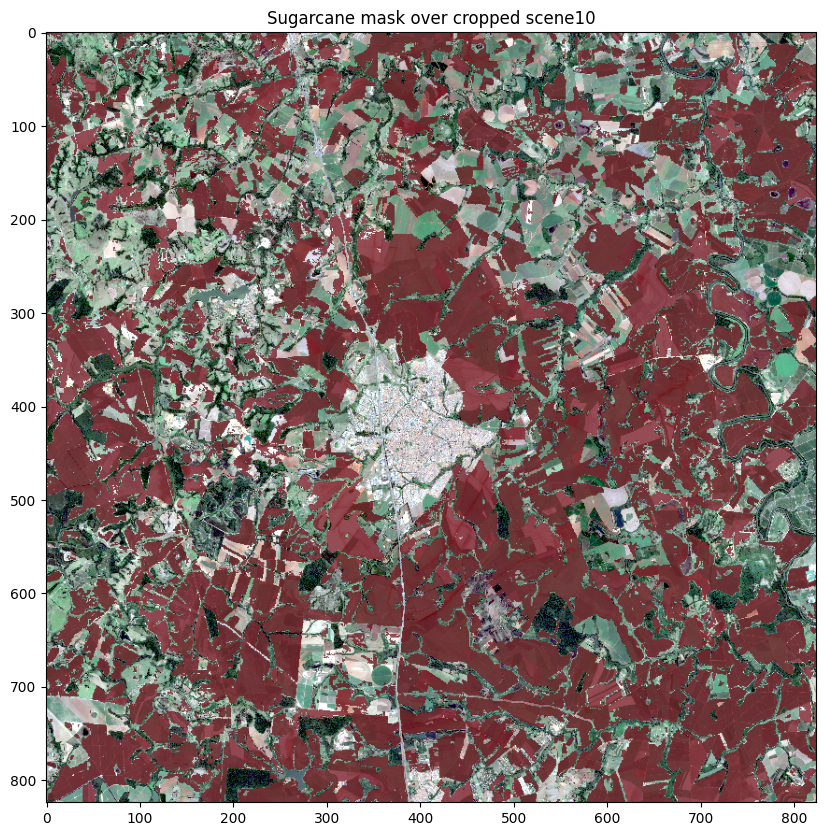

In [260]:
# Scene and mask visualization just to check if everything is working fine

# 1. Using the format for Matplotlib (Height, Width, Bands)
step = 4

# image loading and downsampling for visualization
rgb = X_data[::step, ::step, [2, 1, 0]].copy()
#rgb = rgb[:, :, [2, 1, 0]] # If the bands are in BGR order, you can use this line instead to convert to RGB
rgb = stretch_rgb(rgb)

# mask loading and downsampling for visualization
mask = y_mask[::step, ::step]

# 2. Mask the zero values of the sugarcane mask
# This prevents the background without data from applying a red transparent film over the entire image
y_mask_masked = np.ma.masked_where(mask == 0, mask)

# 3. Render the overlay
plt.figure(figsize=(10, 10))

# Plot the background in real/fake color RGB
plt.imshow(rgb)

# Plot only the active pixels of the mask with a translucent red tone
plt.imshow(y_mask_masked, alpha=0.70, cmap="Reds", vmin=0, vmax=1)

plt.title(f"Sugarcane mask over cropped {scene}")
#plt.axis('off') # Opitional: remove axes with pixel coordinates for a cleaner visual

# Save and display the final aligned result
file_path = base_path / "figures" / f"sugarcane_mask_over_cropped_{scene}.jpg"
plt.savefig(file_path, dpi=300, bbox_inches='tight')
print(f"\nVisualization saved as '{file_path}'")
plt.show()


Visualization saved as '/home/fdesmello/Git/spacesugar/figures/sugarcane_mask_over_scene10.jpg'


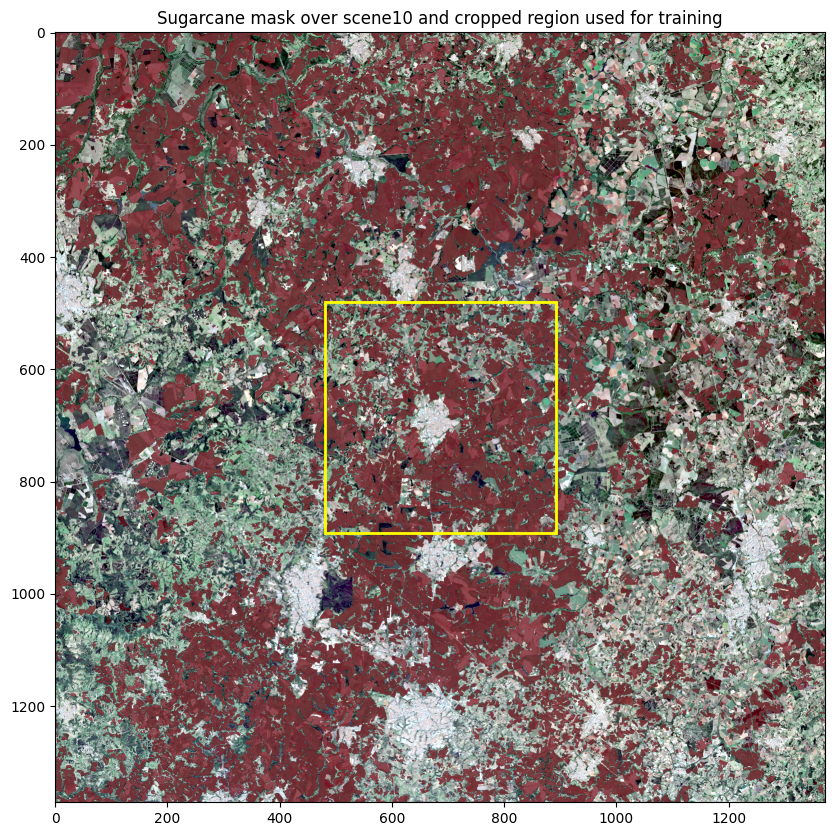

In [261]:
# Preview scene and mask visualization just to check if everything is working fine
x0, x1, y0, y1 = crop

step = 1   # The preview is already downsampled

# RGB image
rgb = X_preview[:, :, [2, 1, 0]].copy()
rgb = stretch_rgb(rgb)

# Mask
mask = np.ma.masked_where(y_preview_mask == 0, y_preview_mask)

# ---------------------------------------------------------
# Create figure
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(rgb)
ax.imshow(mask, alpha=0.70, cmap="Reds", vmin=0, vmax=1)

# ---------------------------------------------------------
# Draw the crop rectangle
# ---------------------------------------------------------

height, width = y_preview_mask.shape

rect = Rectangle(
    (
        x0 * width,
        y0 * height,
    ),
    (x1 - x0) * width,
    (y1 - y0) * height,
    edgecolor="yellow",
    linewidth=2,
    facecolor="none",
)

ax.add_patch(rect)

ax.set_title(f"Sugarcane mask over {scene} and cropped region used for training")
# ax.axis("off")

file_path = base_path / "figures" / f"sugarcane_mask_over_{scene}.jpg"

plt.savefig(file_path, dpi=300, bbox_inches="tight")

print(f"\nVisualization saved as '{file_path}'")

plt.show()